2026-02-04 20:28:01.597166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770236881.779427      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770236881.834656      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770236882.270948      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770236882.270993      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770236882.270995      23 computation_placer.cc:177] computation placer alr

234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1770236958.591513      67 service.cc:152] XLA service 0x7a0088001da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770236958.591557      67 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770236963.068858      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/79 ━━━━━━━━━━━━━━━━━━━━ 34:19 26s/step - accuracy: 0.3438 - loss: 3.4003

I0000 00:00:1770236969.034873      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/79 ━━━━━━━━━━━━━━━━━━━━ 78s 665ms/step - accuracy: 0.5443 - loss: 23.8419 - val_accuracy: 0.7135 - val_loss: 2.1234
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 372ms/step - accuracy: 0.7833 - loss: 1.2471 - val_accuracy: 0.8096 - val_loss: 1.0838
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - accuracy: 0.8059 - loss: 0.9097 - val_accuracy: 0.8540 - val_loss: 0.6230
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 386ms/step - accuracy: 0.8527 - loss: 0.5652 - val_accuracy: 0.8854 - val_loss: 0.3429
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 375ms/step - accuracy: 0.8671 - loss: 0.3624 - val_accuracy: 0.9039 - val_loss: 0.2959
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 31s 386ms/step - accuracy: 0.8925 - loss: 0.2931 - val_accuracy: 0.9020 - val_loss: 0.2809
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 381ms/step - accuracy: 0.8947 - loss: 0.3125 - val_accuracy: 0.9039 - val_loss: 0.3274
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 376ms/step - accuracy: 0.8857 - loss: 0.3389 - val_accurac

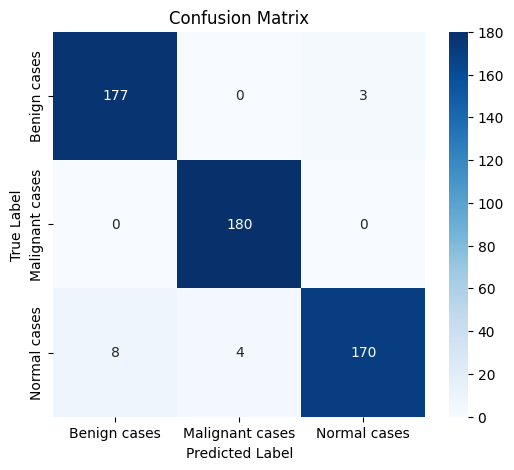

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.resnet_v2 import ResNet152V2, preprocess_input
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ========================
# 1. Load Dataset with CLAHE
# ========================
data_dir = '/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset'
categories = ['Benign cases', 'Malignant cases', 'Normal cases']
num_classes = len(categories)

def load_images(data_dir, img_size=224):
    X, y = [], []
    for cls in categories:
        cls_folder = os.path.join(data_dir, cls)
        for img_file in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue

            # --- Convert to grayscale and apply CLAHE ---
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            enhanced = clahe.apply(gray)

            # --- Back to 3 channels (ResNet expects 3-channel input) ---
            img = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

            # Resize + preprocess for ResNet
            img = cv2.resize(img, (img_size, img_size))
            img = preprocess_input(img)

            X.append(img)
            y.append(cls)

    X = np.array(X, dtype="float32")
    y = LabelEncoder().fit_transform(y)
    y = to_categorical(y, num_classes=num_classes)
    return X, y

X, y = load_images(data_dir)

# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# ========================
# 2. Class Weights
# ========================
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weights = dict(enumerate(class_weights))

# ========================
# 3. Data Augmentation
# ========================
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    brightness_range=[0.8, 1.2]
)
datagen.fit(X_train)

# ========================
# 4. Build ResNet152V2 Model
# ========================
base_model = ResNet152V2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Phase 1: Freeze

model = models.Sequential([
    base_model,

    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ========================
# 5. Train Phase 1
# ========================
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=100,
    class_weight=class_weights,
)

# ========================
# 7. Evaluation
# ========================
val_loss, val_acc = model.evaluate(X_val, y_val)
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# ========================
# 8. Classification Report & Confusion Matrix
# ========================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=categories))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=categories,
            yticklabels=categories)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


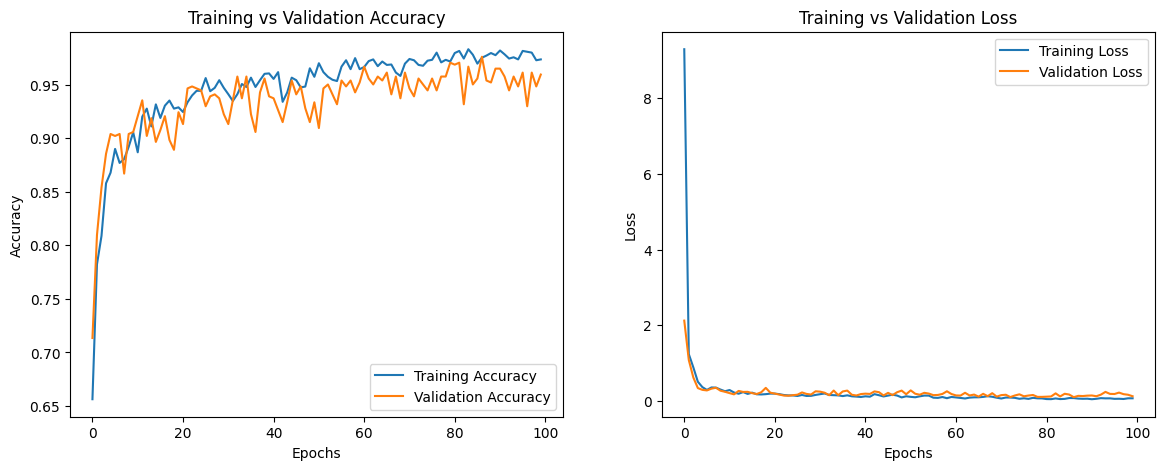

In [2]:
# ========================
# Train vs Validation Accuracy & Loss
# ========================
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()


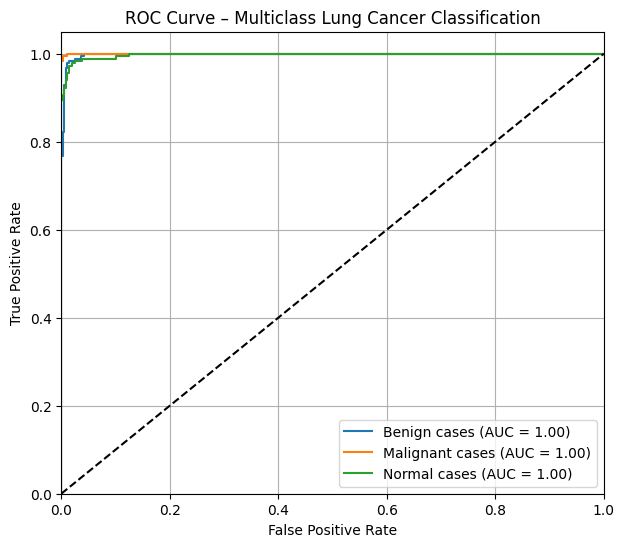

In [3]:
# ========================
# ROC Curve (Multiclass)
# ========================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = num_classes
y_test_bin = label_binarize(y_true, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i],
             label=f'{categories[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Multiclass Lung Cancer Classification')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score


In [5]:
y_labels = np.argmax(y, axis=1)


In [6]:
def build_resnet152v2_model(num_classes):
    base_model = ResNet152V2(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    base_model.trainable = False  # Phase-1 frozen

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [7]:
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold = 1
fold_accuracies = []
fold_losses = []

for train_idx, val_idx in skf.split(X, y_labels):
    print(f"\n========== Fold {fold} ==========")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # ---- Class weights (per fold) ----
    y_train_int = np.argmax(y_train, axis=1)
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train_int),
        y=y_train_int
    )
    class_weights = dict(enumerate(class_weights))

    # ---- Data Augmentation ----
    datagen = ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        shear_range=0.1,
        brightness_range=[0.8, 1.2]
    )
    datagen.fit(X_train)

    # ---- Build model ----
    model = build_resnet152v2_model(num_classes)

    # ---- Train ----
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=32),
        validation_data=(X_val, y_val),
        epochs=50,
        class_weight=class_weights,
        verbose=1
    )

    # ---- Evaluate ----
    loss, acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"Fold {fold} Validation Accuracy: {acc*100:.2f}%")

    fold_accuracies.append(acc)
    fold_losses.append(loss)

    fold += 1



========== Fold 1 ==========


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 76s 600ms/step - accuracy: 0.6059 - loss: 14.7432 - val_accuracy: 0.7812 - val_loss: 0.9461
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 371ms/step - accuracy: 0.8018 - loss: 0.8030 - val_accuracy: 0.8573 - val_loss: 0.3524
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 369ms/step - accuracy: 0.8099 - loss: 0.5975 - val_accuracy: 0.8809 - val_loss: 0.3174
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 370ms/step - accuracy: 0.8467 - loss: 0.4323 - val_accuracy: 0.8601 - val_loss: 0.4412
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 371ms/step - accuracy: 0.8533 - loss: 0.4250 - val_accuracy: 0.8615 - val_loss: 0.3791
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 368ms/step - accuracy: 0.8678 - loss: 0.3689 - val_accuracy: 0.9017 - val_loss: 0.2692
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 370ms/step - accuracy: 0.8508 - loss: 0.4360 - val_accuracy: 0.9252 - val_loss: 0.2262
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 373ms/step - accuracy: 0.8963 - loss: 0.2525 - val_acc

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 73s 567ms/step - accuracy: 0.5523 - loss: 19.9563 - val_accuracy: 0.7521 - val_loss: 1.6023
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 364ms/step - accuracy: 0.7822 - loss: 1.1463 - val_accuracy: 0.7618 - val_loss: 0.9299
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 367ms/step - accuracy: 0.8500 - loss: 0.4990 - val_accuracy: 0.8892 - val_loss: 0.3074
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 363ms/step - accuracy: 0.8672 - loss: 0.3609 - val_accuracy: 0.8061 - val_loss: 0.5822
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 365ms/step - accuracy: 0.8586 - loss: 0.4005 - val_accuracy: 0.9197 - val_loss: 0.2177
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 369ms/step - accuracy: 0.9005 - loss: 0.2697 - val_accuracy: 0.9169 - val_loss: 0.2357
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 369ms/step - accuracy: 0.8812 - loss: 0.3805 - val_accuracy: 0.8407 - val_loss: 0.5063
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 33s 364ms/step - accuracy: 0.8780 - loss: 0.3553 - val_acc

...

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 73s 566ms/step - accuracy: 0.5513 - loss: 16.8769 - val_accuracy: 0.7119 - val_loss: 2.2857
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 370ms/step - accuracy: 0.7667 - loss: 1.3959 - val_accuracy: 0.8130 - val_loss: 0.5154
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 373ms/step - accuracy: 0.8156 - loss: 0.6122 - val_accuracy: 0.8837 - val_loss: 0.2775
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 371ms/step - accuracy: 0.8870 - loss: 0.3273 - val_accuracy: 0.8961 - val_loss: 0.2630
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step - accuracy: 0.8769 - loss: 0.2855 - val_accuracy: 0.9072 - val_loss: 0.2303
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 376ms/step - accuracy: 0.9056 - loss: 0.2476 - val_accuracy: 0.8643 - val_loss: 0.3339
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 379ms/step - accuracy: 0.8853 - loss: 0.3066 - val_accuracy: 0.8546 - val_loss: 0.6055
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 386ms/step - accuracy: 0.8829 - loss: 0.3275 - val_acc

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 79s 600ms/step - accuracy: 0.5908 - loss: 11.3090 - val_accuracy: 0.8241 - val_loss: 0.9307
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 383ms/step - accuracy: 0.7721 - loss: 1.5289 - val_accuracy: 0.8532 - val_loss: 0.6386
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 388ms/step - accuracy: 0.8341 - loss: 0.5970 - val_accuracy: 0.8712 - val_loss: 0.3559
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 382ms/step - accuracy: 0.8551 - loss: 0.4631 - val_accuracy: 0.8947 - val_loss: 0.2616
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 377ms/step - accuracy: 0.8714 - loss: 0.3699 - val_accuracy: 0.8850 - val_loss: 0.3202
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 371ms/step - accuracy: 0.8951 - loss: 0.3258 - val_accuracy: 0.9197 - val_loss: 0.2408
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step - accuracy: 0.8907 - loss: 0.2963 - val_accuracy: 0.9100 - val_loss: 0.2434
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 373ms/step - accuracy: 0.9063 - loss: 0.2671 - val_acc

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 80s 630ms/step - accuracy: 0.5614 - loss: 18.0446 - val_accuracy: 0.7254 - val_loss: 1.5751
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 376ms/step - accuracy: 0.7805 - loss: 0.9120 - val_accuracy: 0.8558 - val_loss: 0.3597
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 383ms/step - accuracy: 0.8687 - loss: 0.3488 - val_accuracy: 0.8308 - val_loss: 0.4177
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 375ms/step - accuracy: 0.8637 - loss: 0.3775 - val_accuracy: 0.8447 - val_loss: 0.3993
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 383ms/step - accuracy: 0.8814 - loss: 0.3511 - val_accuracy: 0.9140 - val_loss: 0.1963
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 376ms/step - accuracy: 0.8904 - loss: 0.3036 - val_accuracy: 0.8655 - val_loss: 0.4274
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 379ms/step - accuracy: 0.8940 - loss: 0.2900 - val_accuracy: 0.8544 - val_loss: 0.4702
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step - accuracy: 0.8811 - loss: 0.3761 - val_acc

In [8]:
print("\n==============================")
print("Cross-Validation Results")
print("==============================")
print(f"Mean Accuracy: {np.mean(fold_accuracies)*100:.2f}%")
print(f"Std Accuracy: {np.std(fold_accuracies)*100:.2f}%")



Cross-Validation Results
Mean Accuracy: 95.84%
Std Accuracy: 1.16%


In [9]:
def get_gradcam(model, img_array, class_index=None, base_model=None):
    """
    model      : trained Sequential model
    img_array  : shape (1, 224, 224, 3), already preprocessed
    base_model : the ResNet152V2 instance you added to Sequential
    """

    if base_model is None:
        raise ValueError("You must pass the base_model used in Sequential!")

    # Last conv layer in ResNet152V2
    last_conv_layer = base_model.get_layer("conv5_block3_out")

    # Grad-CAM model
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


In [10]:
def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)
    return overlay


In [11]:
idx = 10
input_img = np.expand_dims(X_test[idx], axis=0)
original_img = ((X_test[idx] + 1) * 127.5).astype(np.uint8)

heatmap = get_gradcam(model, input_img, base_model=base_model)
overlay_img = overlay_gradcam(original_img, heatmap)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay_img)
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.show()

pred_class = categories[np.argmax(model.predict(input_img))]
print("Predicted Class:", pred_class)


AttributeError: The layer sequential_5 has never been called and thus has no defined input.

In [ ]:
model.save("/kaggle/working/ResNet152.h5")